# Information Retrieval: From Keywords to Transformers

## Traditional vs Semantic Search


## 🛠️ Setup and Imports

In [1]:
# Core libraries
import sys
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import logging
import warnings

# Suppress verbose logging from gensim and word2vec
logging.getLogger('gensim').setLevel(logging.WARNING)
logging.getLogger('word2vec_retriever').setLevel(logging.WARNING)
logging.getLogger("headroom.integrations.langchain.retriever").setLevel(
    logging.WARNING
)

# Suppress gensim warnings and exceptions
warnings.filterwarnings("ignore", category=UserWarning, module="gensim")
warnings.filterwarnings("ignore", message=".*gensim.models.word2vec_inner.*")

# Add src to path for our utilities
sys.path.append('../src')

# Our utility modules
from data_loader import DataLoader
from bm25_retriever import BM25Retriever
from transformer_retriever import TransformerRetriever
from evaluator import IRMetrics
from utils import create_comparison_visualization, print_comparison_table, measure_latency
print("✅ Libraries and utilities loaded")
print("📚 Ready to explore traditional vs semantic retrieval!")

/home/rahulahuja/anaconda3/envs/headroom/lib/python3.12/site-packages/beir/util.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


✅ Libraries and utilities loaded
📚 Ready to explore traditional vs semantic retrieval!


In [2]:
from langchain_core.documents import Document
from headroom.integrations import HeadroomDocumentCompressor

## 📥 Load Natural Questions Dataset

In [3]:
print("📥 Loading Natural Questions dataset with smart sampling...\n")

# Suppress verbose logging from data_loader
import logging
logging.getLogger('data_loader').setLevel(logging.WARNING)

# Load with manageable sample for educational demonstration
loader = DataLoader("BeIR/nq")
dataset = loader.load_dataset(split="test", query_sample_size=2000, random_seed=42)
corpus_texts, query_texts, qrels_dict = loader.prepare_retrieval_data()

print(f"✅ Dataset loaded:")
print(f"  📄 Documents: {len(corpus_texts):,}")
print(f"  ❓ Queries: {len(query_texts):,}")
print(f"  🔗 Query-document pairs: {len(qrels_dict):,}")

# Show examples to understand the task
print(f"\n💡 Example Query-Document Pair:")
print(f"  Query: '{query_texts[0]}'")
if 0 in qrels_dict:
    rel_doc_id = list(qrels_dict[0].keys())[0]
    print(f"  Relevant doc: '{corpus_texts[rel_doc_id][:120]}...'")

INFO:beir.util:Downloading nq.zip ...


📥 Loading Natural Questions dataset with smart sampling...



/home/rahulahuja/headroom/kth_task/dataset/nq.zip:   0%|          | 0.00/475M [00:00<?, ?iB/s]

INFO:beir.util:Unzipping nq.zip ...
INFO:beir.datasets.data_loader:Loading Corpus...


  0%|          | 0/2681468 [00:00<?, ?it/s]

INFO:beir.datasets.data_loader:Loaded 2681468 TEST Documents.
INFO:beir.datasets.data_loader:Doc Example: {'text': "In accounting, minority interest (or non-controlling interest) is the portion of a subsidiary corporation's stock that is not owned by the parent corporation. The magnitude of the minority interest in the subsidiary company is generally less than 50% of outstanding shares, or the corporation would generally cease to be a subsidiary of the parent.[1]", 'title': 'Minority interest'}
INFO:beir.datasets.data_loader:Loading Queries...
INFO:beir.datasets.data_loader:Loaded 3452 TEST Queries.
INFO:beir.datasets.data_loader:Query Example: what is non controlling interest on balance sheet


✅ Dataset loaded:
  📄 Documents: 2,440
  ❓ Queries: 2,000
  🔗 Query-document pairs: 2,000

💡 Example Query-Document Pair:
  Query: 'where do they get the hair for a hair transplant'
  Relevant doc: 'Hair transplantation is a surgical technique that removes hair follicles from one part of the body, called the 'donor si...'


In [8]:
# Convert corpus into LangChain Documents.
# Preserve the original corpus ID through metadata.

documents = [Document(page_content=text, metadata={"doc_id": i})
    for i, text in enumerate(corpus_texts)]


# Retrieval Method Comparisons

##  Method 1: Traditional Keyword-Based Retrieval (BM25)

**How BM25 Works:**
1. **Term Frequency (TF)**: How often does a word appear in a document?
2. **Inverse Document Frequency (IDF)**: How rare is the word across the corpus?
3. **Document Length Normalization**: Adjust for document length differences

In [31]:
print("🔤 Building BM25 Index...")

# Initialize and build BM25 index
bm25_retriever = BM25Retriever()
bm25_retriever.build_index(corpus_texts)

# Run retrieval
bm25_results = bm25_retriever.retrieve(query_texts, k=20)

# Evaluate performance
bm25_metrics = IRMetrics.evaluate_retrieval(bm25_results, qrels_dict)
IRMetrics.print_metrics(bm25_metrics, "BM25 (Keyword-Based) Results")

🔤 Building BM25 Index...
🔧 Building BM25 index...
✅ BM25 index built for 2,440 documents
🔍 Running BM25 retrieval for 2000 queries...


Retrieving: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:10<00:00, 192.23it/s]

✅ Retrieved top-20 documents for 2000 queries

📊 BM25 (Keyword-Based) Results
Recall@1    : 0.5328
Recall@5    : 0.7266
Recall@10   : 0.7740
Precision@5 : 0.1751
MRR         : 0.6738


## <img src="https://www.headroomlabs.ai/favicon.svg"/> Method 2: Headroom's Compressor (Retrieval)
How it works:
It has modified BM25 without TF-IDF statistics being used

In [12]:
print("🔤 Running Headroom...")

# Headroom's original BM25-style document compressor
headroom_compressor = HeadroomDocumentCompressor(
    max_documents=20,
    min_relevance=0.0,
    prefer_diverse=False,
)

print(f"📄 Headroom corpus: {len(documents):,} documents")

🔤 Running Headroom...
📄 Headroom corpus: 2,440 documents


In [11]:
print("🔍 Running Headroom BM25 retrieval...")

headroom_compressor_results = {}

for query_id, query in enumerate(query_texts):
    docs = headroom_compressor.compress_documents(documents, query)

    headroom_compressor_results[query_id] = [ doc.metadata["doc_id"] for doc in docs]
    
print(f"✅ Retrieved top-{headroom_compressor.max_documents} "
    f"documents for {len(query_texts)} queries")

🔍 Running Headroom BM25 retrieval...
✅ Retrieved top-20 documents for 2000 queries


In [12]:
# Evaluate performance
headroom_compressor_metrics = IRMetrics.evaluate_retrieval(headroom_compressor_results, qrels_dict)
IRMetrics.print_metrics(headroom_compressor_metrics, "headroom_bm25_metrics Results")


📊 headroom_bm25_metrics Results
Recall@1    : 0.4552
Recall@5    : 0.6361
Recall@10   : 0.6976
Precision@5 : 0.1512
MRR         : 0.5882


## 🧠 Method 3: Transformer-Based Semantic Retrieval

Transformers is a neural network using attention mechanism to train on long context. More details can be found in the original paper "Attention is all you need" https://arxiv.org/abs/1706.03762

In [19]:
print("🧠 Building Transformer-Based Semantic Index...")

# Initialize transformer retriever with a lightweight model
transformer_retriever = TransformerRetriever(model_name="all-MiniLM-L6-v2")
transformer_retriever.build_index(corpus_texts)

# Run semantic retrieval
transformer_results = transformer_retriever.retrieve(query_texts, k=20)

# Evaluate performance
transformer_metrics = IRMetrics.evaluate_retrieval(transformer_results, qrels_dict)
IRMetrics.print_metrics(transformer_metrics, "Transformer (Semantic) Results")

INFO:sentence_transformers.base.model:No device provided, using cpu


🧠 Building Transformer-Based Semantic Index...
🤖 Loading transformer model: all-MiniLM-L6-v2


INFO:sentence_transformers.base.model:Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ Model loaded: all-MiniLM-L6-v2
🧠 Building semantic index...


Batches:   0%|          | 0/77 [00:00<?, ?it/s]

✅ Semantic index built for 2,440 documents
   Embedding dimension: 384
🔍 Running semantic retrieval for 2000 queries...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

✅ Retrieved top-20 documents using semantic similarity

📊 Transformer (Semantic) Results
Recall@1    : 0.7760
Recall@5    : 0.9298
Recall@10   : 0.9497
Precision@5 : 0.2263
MRR         : 0.9044


## 📊 Comparison: Evolution of Text Representations

Let's compare how well each method performs, showing the evolution from keywords → static embeddings → contextual embeddings.

📊 Comparing All Three Methods
📊 All Methods Comparison
Recall@1    : Headroom Compressor=0.4552 | BM25 (Keywords)=0.5328 | Transformer (Contextual)=0.7760
Recall@5    : Headroom Compressor=0.6361 | BM25 (Keywords)=0.7266 | Transformer (Contextual)=0.9298
Recall@10   : Headroom Compressor=0.6976 | BM25 (Keywords)=0.7740 | Transformer (Contextual)=0.9497
Precision@5 : Headroom Compressor=0.1512 | BM25 (Keywords)=0.1751 | Transformer (Contextual)=0.2263
MRR         : Headroom Compressor=0.5882 | BM25 (Keywords)=0.6738 | Transformer (Contextual)=0.9044


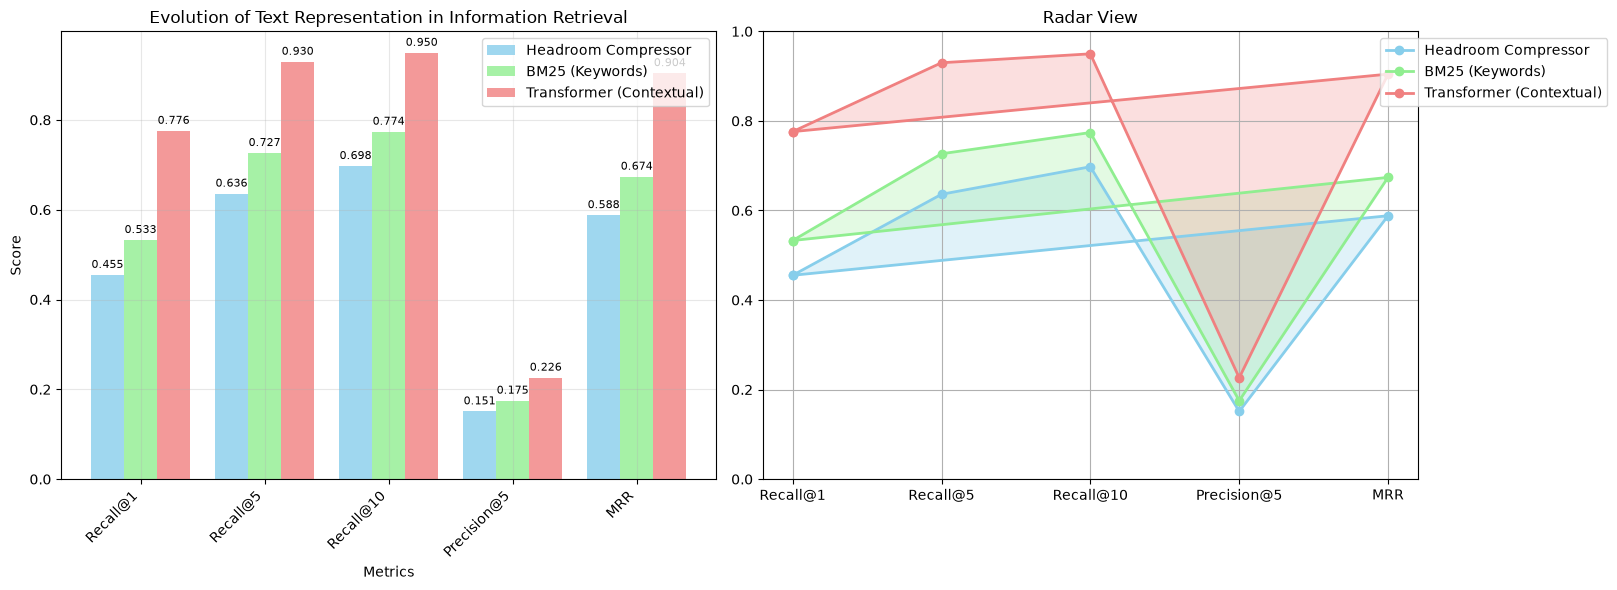


🎯 Evolution Summary:
   📊 BM25: Keyword matching - fast but limited semantic understanding
   📊 Word2Vec: Static embeddings - learns word relationships but struggles with small corpus
   📊 Transformer: Contextual embeddings - full semantic and contextual understanding
   • Higher scores are better for all metrics
   • Recall@k: What fraction of relevant docs are found in top k results?
   • Precision@k: What fraction of top k results are actually relevant?
   • MRR (Mean Reciprocal Rank): How well does the method rank relevant docs?


In [36]:
print("📊 Comparing All Three Methods")
print("=" * 70)

# Create comparison using utility function
comparison_metrics = {
    'Headroom Compressor': headroom_compressor_metrics,
    'BM25 (Keywords)': bm25_metrics,
    'Transformer (Contextual)': transformer_metrics
}

# Print comparison table
print_comparison_table(comparison_metrics, title="All Methods Comparison")

# Create visualization
create_comparison_visualization(
    comparison_metrics, 
    title="Evolution of Text Representation in Information Retrieval",
    figsize=(16, 6),
    show_values=True,
    show_radar=True
)

print("\n🎯 Evolution Summary:")
print("   📊 BM25: Keyword matching - fast but limited semantic understanding")
print("   📊 Transformer: Contextual embeddings - full semantic and contextual understanding")
print("   • Higher scores are better for all metrics")
print("   • Recall@k: What fraction of relevant docs are found in top k results?")
print("   • Precision@k: What fraction of top k results are actually relevant?")
print("   • MRR (Mean Reciprocal Rank): How well does the method rank relevant docs?")

## 🔍 Example Analysis: Evolution in Action

Let's examine specific examples to understand the progression from keywords → static embeddings → contextual embeddings.

In [37]:
from utils import compare_retrieval_methods

results_dict = {
    'Headroom': headroom_compressor_results,
    'BM25': bm25_results,
    'Transformer': transformer_results
}

stats = compare_retrieval_methods(
    query_texts=query_texts,
    corpus_texts=corpus_texts,
    qrels_dict=qrels_dict,
    results_dict=results_dict,
    n_examples=10
)


Retrieval Method Comparison

Example 1: 'who played bailey in the sisterhood of the traveling pants'
Ground Truth: 1 relevant document(s)

Relevant Documents:
   1. Jenna Boyd was born in Bedford, Texas and moved with her parents and younger brother Cayden (also an actor) to Los Angel...

Headroom (Top 1):
   1. ✓ Jenna Boyd was born in Bedford, Texas and moved with her parents and younger brother Cayden (also an actor) to Los Angel...

BM25 (Top 1):
   1. ✗ Jesse Wesley Williams (born August 5, 1981)[2] is an American actor, director, teacher and activist, best known for his ...

Transformer (Top 1):
   1. ✓ Jenna Boyd was born in Bedford, Texas and moved with her parents and younger brother Cayden (also an actor) to Los Angel...

Example 2: 'what happens to will and elizabeth in pirates of the caribbean 3'
Ground Truth: 1 relevant document(s)

Relevant Documents:
   1. Elizabeth bids Jack, Barbossa, and the pirates farewell before reuniting with Will for their "one day" on a deserted

# Demo copied into the ANALYZE.md

In [9]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_classic.retrievers import ContextualCompressionRetriever
from headroom_bm25 import HeadroomBM25DocumentCompressor
from headroom_transformer import HeadroomTransformerDocumentCompressor
from utils import measure_latency

/tmp/ipykernel_13049/2805735493.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [10]:
# initial setup of embeddings and vector databases

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

vectorstore = FAISS.from_documents(documents, embeddings)

base_retriever = vectorstore.as_retriever(
    search_kwargs={"k": 100})

query = "Which Doctor performed Caesarean?"
docs = base_retriever.invoke(query)

INFO:sentence_transformers.base.model:No device provided, using cpu
INFO:sentence_transformers.base.model:Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

INFO:faiss.loader:Loading faiss with AVX512 support.
INFO:faiss.loader:Could not load library with AVX512 support due to:
ModuleNotFoundError("No module named 'faiss.swigfaiss_avx512'")
INFO:faiss.loader:Loading faiss with AVX2 support.
INFO:faiss.loader:Could not load library with AVX2 support due to:
ModuleNotFoundError("No module named 'faiss.swigfaiss_avx2'")
INFO:faiss.loader:Loading faiss.
INFO:faiss.loader:Successfully loaded faiss.


In [12]:
headroom_compressor = HeadroomDocumentCompressor(
    max_documents=20,
    min_relevance=0.0,
    prefer_diverse=False,
)

@measure_latency
def headroom_compress(query: str):
    compressed = headroom_compressor.compress_documents(docs, query)
    return compressed

# usage
results = headroom_compress(query)
print(results[0].page_content)


headroom_compress took 0.0032 seconds
Dr. Jesse Bennett (July 10, 1769 â€”July 13, 1842) was the first American physician to perform a successful Caesarean section, which he performed on his own wife at the birth of their only child on January 14, 1794.[1][2]


In [13]:
#sunk cost of indexing
headroom_bm25 = HeadroomBM25DocumentCompressor(
    corpus_texts=corpus_texts, # sunk costs
    max_documents=20,
    min_relevance=0.3,
)

@measure_latency
def headroom_bm25_compress(query: str):
    return headroom_bm25.compress_documents(docs, query)

# usage
results = headroom_bm25_compress("Which Doctor performed Caesarean?")
print(results[0].page_content)

🔧 Building BM25 index...
✅ BM25 index built for 2,440 documents
headroom_bm25_compress took 0.0247 seconds
They realise that this was a trap arranged by Kovarian, as the Silence begin to escape confinement and overload the eyedrives (including Madame Kovarian's), killing their users. The Doctor and River escape to the top of the pyramid while Amy and Rory fight off a wave of Silence and Amy realises who Rory is. Madame Kovarian dislodges her own eyedrive as it begins to overload, but Amy forces it back in place with the intention of killing her as revenge for Kovarian taking her child (Melody Pond) away. Amy and Rory regroup with River and the Doctor. River tries to convince the Doctor that this frozen timeline is acceptable and that he does not have to die, but the Doctor explains that all of reality will soon break down. River claims she'll suffer more than anyone else in the universe if she has to kill the Doctor, despite his horror at the idea. To stop it, the Doctor marries River 

In [14]:
#sunk cost of indexing
headroom_transformer = HeadroomTransformerDocumentCompressor(
    corpus_texts=corpus_texts, #sunk cost
    max_documents=10,
    min_relevance=0.0,
)

@measure_latency
def headroom_transformer_compress(query: str):
    return headroom_transformer.compress_documents(docs, query)

# usage
results = headroom_transformer_compress("Which Doctor performed Caesarean?")
print(results[0].page_content)

INFO:sentence_transformers.base.model:No device provided, using cpu


🤖 Loading transformer model: all-MiniLM-L6-v2


INFO:sentence_transformers.base.model:Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ Model loaded: all-MiniLM-L6-v2
🧠 Building semantic index...


Batches:   0%|          | 0/77 [00:00<?, ?it/s]

✅ Semantic index built for 2,440 documents
   Embedding dimension: 384


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

headroom_transformer_compress took 0.3311 seconds
Dr. Jesse Bennett (July 10, 1769 â€”July 13, 1842) was the first American physician to perform a successful Caesarean section, which he performed on his own wife at the birth of their only child on January 14, 1794.[1][2]
